In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = pd.read_csv("/content/monthly_milk_production.csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [ ]:
df.shape

(168, 2)

In [ ]:
df.columns

Index(['Date', 'Production'], dtype='object')

In [ ]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [ ]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Date          0
Production    0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
Date          0.0
Production    0.0
dtype: float64


In [ ]:
df = df.interpolate(method='linear')

print("Missing values after interpolation:")
print(df.isnull().sum())

Missing values after interpolation:
Date          0
Production    0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
Date          0.0
Production    0.0
dtype: float64


In [ ]:
df = df.interpolate(method='linear')

print("Missing values after interpolation:")
print(df.isnull().sum())

Missing values after interpolation:
Date          0
Production    0
dtype: int64


In [ ]:
df = df.ffill().bfill()

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (168, 2)


In [ ]:
print(df.columns.tolist())

['Date', 'Production']


In [ ]:
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(by=date_col)
df = df.reset_index(drop=True)
print(df.head())

        Date  Production
0 1962-01-01         589
1 1962-02-01         561
2 1962-03-01         640
3 1962-04-01         656
4 1962-05-01         727


In [ ]:
print(df.dtypes)

Date          datetime64[ns]
Production             int64
dtype: object


In [ ]:
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

In [ ]:
df[target_col] = df[target_col].interpolate()
df[target_col] = df[target_col].ffill().bfill()

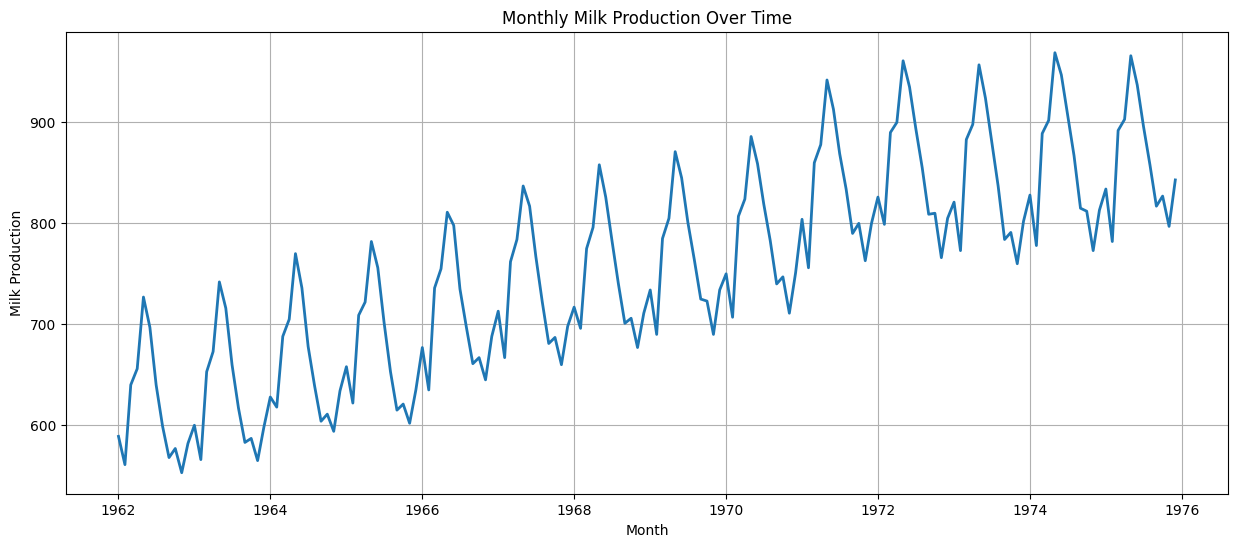

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    df[date_col],
    df[target_col],
    linewidth=2
)

plt.title("Monthly Milk Production Over Time")
plt.xlabel("Month")
plt.ylabel("Milk Production")
plt.grid(True)

plt.show()

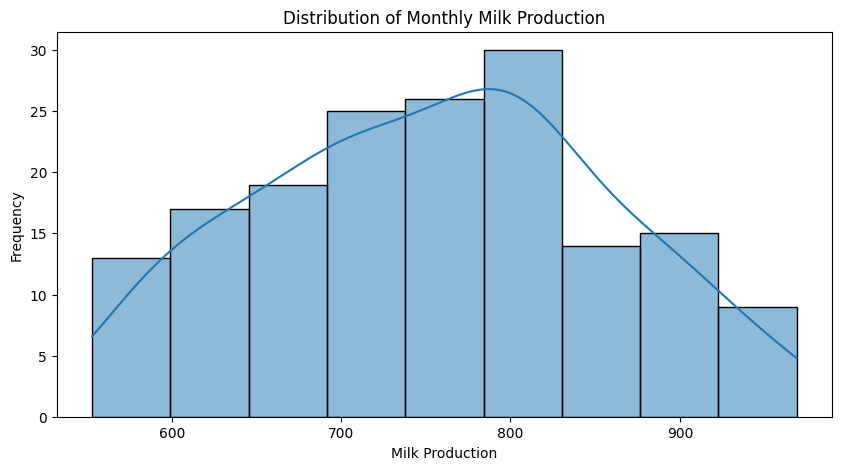

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df[target_col],
    kde=True
)

plt.title("Distribution of Monthly Milk Production")
plt.xlabel("Milk Production")
plt.ylabel("Frequency")

plt.show()

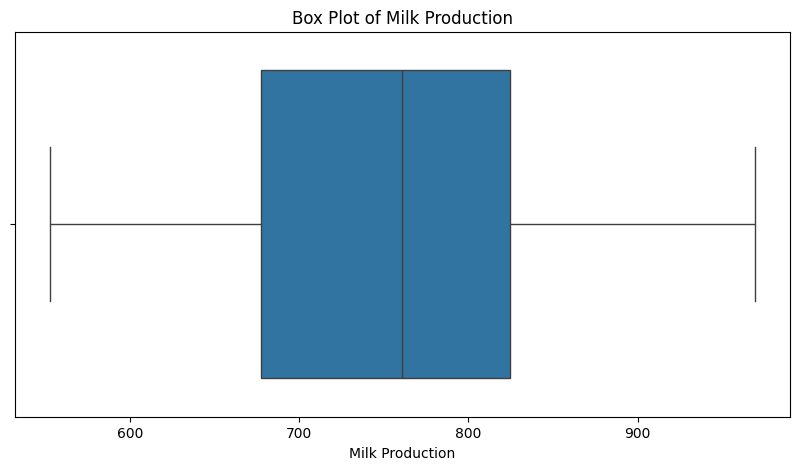

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df[target_col])

plt.title("Box Plot of Milk Production")
plt.xlabel("Milk Production")

plt.show()

In [ ]:
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df[target_col] < lower_bound) |
    (df[target_col] > upper_bound)
]

print("Number of outliers:", len(outliers))

display(outliers)

Number of outliers: 0


,Date,Production


In [ ]:
df[target_col] = df[target_col].clip(
    lower=lower_bound,
    upper=upper_bound
)

In [ ]:
df['Month_Number'] = df[date_col].dt.month

monthly_average = df.groupby(
    'Month_Number'
)[target_col].mean()

print(monthly_average)

Month_Number
1     727.071429
2     689.285714
3     783.500000
4     800.071429
5     862.785714
6     836.142857
7     788.071429
8     747.500000
9     706.642857
10    711.857143
11    682.571429
12    721.000000
Name: Production, dtype: float64


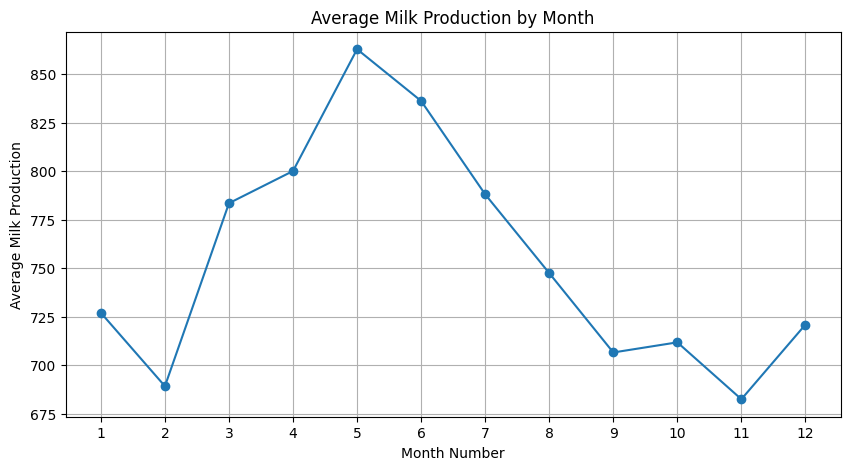

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker='o'
)

plt.title("Average Milk Production by Month")
plt.xlabel("Month Number")
plt.ylabel("Average Milk Production")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

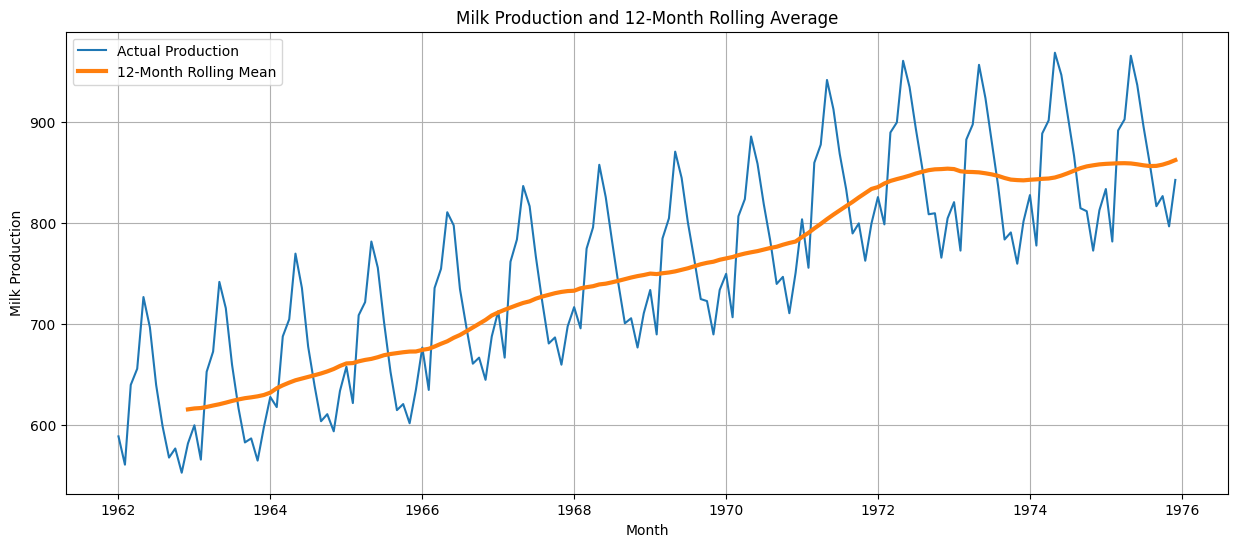

In [ ]:
df['Rolling_Mean'] = df[target_col].rolling(
    window=12
).mean()

plt.figure(figsize=(15, 6))

plt.plot(
    df[date_col],
    df[target_col],
    label='Actual Production'
)

plt.plot(
    df[date_col],
    df['Rolling_Mean'],
    label='12-Month Rolling Mean',
    linewidth=3
)

plt.title("Milk Production and 12-Month Rolling Average")
plt.xlabel("Month")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
data = df[[date_col, target_col]].copy()
data.head()

,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727


In [ ]:
values = data[target_col].values.reshape(-1, 1)
print("Number of observations:", len(values))

Number of observations: 168


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)
print(scaled_values[:5])

[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


In [ ]:
n = len(scaled_values)

train_size = int(n * 0.70)
val_size = int(n * 0.15)

train_data = scaled_values[:train_size]

val_data = scaled_values[
    train_size:train_size + val_size
]

test_data = scaled_values[
    train_size + val_size:
]

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Testing samples:", len(test_data))

Training samples: 117
Validation samples: 25
Testing samples: 26


In [ ]:
window_size = 12

In [ ]:
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = create_sequences(
    train_data,
    window_size
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (105, 12, 1)
y_train shape: (105, 1)


In [ ]:
val_input = scaled_values[
    train_size - window_size:
    train_size + val_size
]

X_val, y_val = create_sequences(
    val_input,
    window_size
)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (25, 12, 1)
y_val shape: (25, 1)


In [ ]:
test_input = scaled_values[
    train_size + val_size - window_size:
]

X_test, y_test = create_sequences(
    test_input,
    window_size
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (26, 12, 1)
y_test shape: (26, 1)


In [ ]:
rnn_model = Sequential([
    SimpleRNN(
        64,
        activation='tanh',
        input_shape=(window_size, 1)
    ),

    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.1402 - val_loss: 0.0209
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0305 - val_loss: 0.0532
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0209 - val_loss: 0.0067
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0191 - val_loss: 0.0082
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0117 - val_loss: 0.0048
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0079 - val_loss: 0.0058
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0094 - val_loss: 0.0047
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0083 - val_loss: 0.0045
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0069 - val_loss: 0.0043
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0083 - val_loss: 0.0037
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0055 - val_loss: 0.0062
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0069 - val_lo

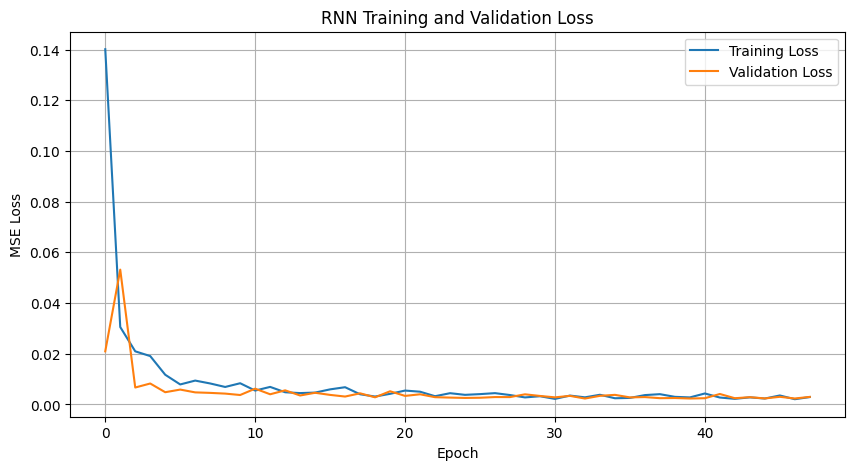

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    rnn_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    rnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.title("RNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
lstm_model = Sequential([
    LSTM(
        64,
        activation='tanh',
        input_shape=(window_size, 1)
    ),

    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.1407 - val_loss: 0.1544
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0420 - val_loss: 0.0241
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0374 - val_loss: 0.0318
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0313 - val_loss: 0.0285
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0263 - val_loss: 0.0345
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0269 - val_loss: 0.0262
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0269 - val_loss: 0.0226
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0250 - val_loss: 0.0227
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0234 - val_loss: 0.0245
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0221 - val_loss: 0.0241
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0256 - val_loss: 0.0221
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0229 - val_l

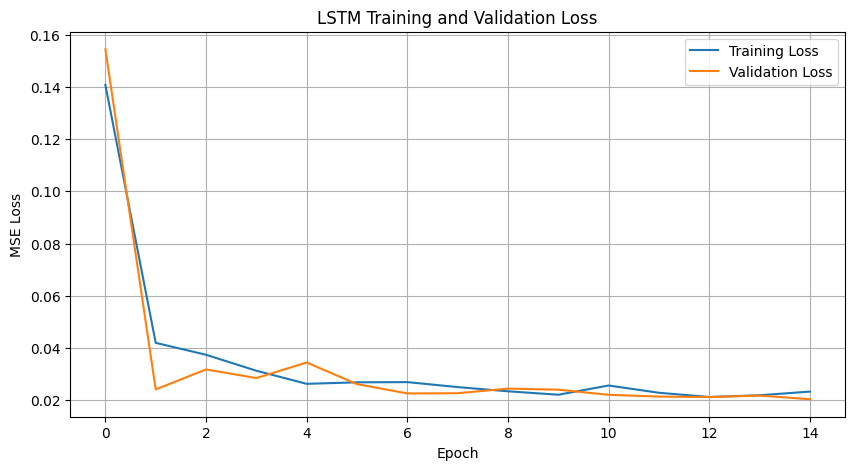

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    lstm_history.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
gru_model = Sequential([
    GRU(
        64,
        activation='tanh',
        input_shape=(window_size, 1)
    ),

    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.1694 - val_loss: 0.2454
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0570 - val_loss: 0.0391
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0259 - val_loss: 0.0237
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0294 - val_loss: 0.0256
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0234 - val_loss: 0.0401
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0214 - val_loss: 0.0282
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0207 - val_loss: 0.0198
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0204 - val_loss: 0.0198
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0183 - val_loss: 0.0256
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0176 - val_loss: 0.0249
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0171 - val_loss: 0.0190
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0173 - val_lo

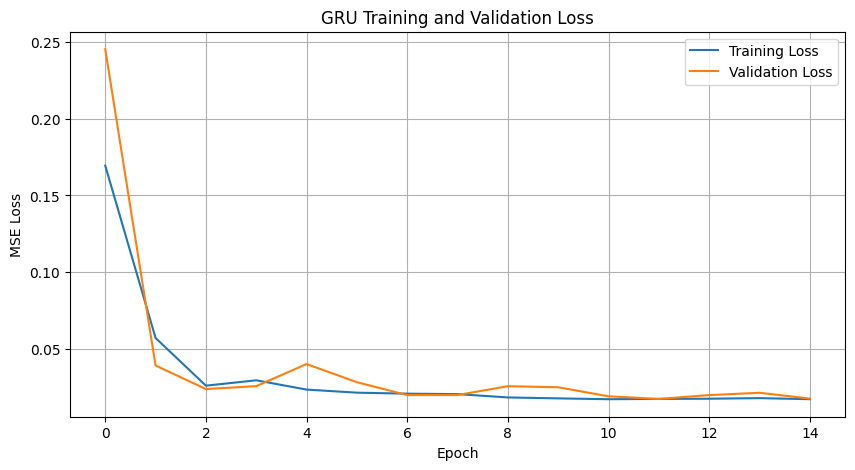

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    gru_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    gru_history.history['val_loss'],
    label='Validation Loss'
)

plt.title("GRU Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
rnn_pred_scaled = rnn_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


In [ ]:
lstm_pred_scaled = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


In [ ]:
gru_pred_scaled = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step


In [ ]:
rnn_pred = scaler.inverse_transform(
    rnn_pred_scaled
).flatten()

lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled
).flatten()

gru_pred = scaler.inverse_transform(
    gru_pred_scaled
).flatten()

actual = scaler.inverse_transform(
    y_test
).flatten()

In [ ]:
def calculate_metrics(actual, predicted):

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    # Avoid division by zero
    non_zero = actual != 0

    mape = np.mean(
        np.abs(
            (actual[non_zero] - predicted[non_zero])
            / actual[non_zero]
        )
    ) * 100

    return rmse, mae, mape

In [ ]:
rnn_rmse, rnn_mae, rnn_mape = calculate_metrics(
    actual,
    rnn_pred
)

print("RNN Results")
print("RMSE:", rnn_rmse)
print("MAE:", rnn_mae)
print("MAPE:", rnn_mape, "%")

RNN Results
RMSE: 15.90066891422433
MAE: 13.360868013822106
MAPE: 1.5453643270327186 %


In [ ]:
lstm_rmse, lstm_mae, lstm_mape = calculate_metrics(
    actual,
    lstm_pred
)

print("LSTM Results")
print("RMSE:", lstm_rmse)
print("MAE:", lstm_mae)
print("MAPE:", lstm_mape, "%")

LSTM Results
RMSE: 168.5973860271127
MAE: 156.81589918870193
MAPE: 17.944608975028114 %


In [ ]:
gru_rmse, gru_mae, gru_mape = calculate_metrics(
    actual,
    gru_pred
)

print("GRU Results")
print("RMSE:", gru_rmse)
print("MAE:", gru_mae)
print("MAPE:", gru_mape, "%")

GRU Results
RMSE: 212.6256170309835
MAE: 204.30176485501804
MAPE: 23.554457297930455 %


In [ ]:
results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse],
    'MAE': [rnn_mae, lstm_mae, gru_mae],
    'MAPE (%)': [rnn_mape, lstm_mape, gru_mape]
})

results

,Model,RMSE,MAE,MAPE (%)
0,RNN,15.900669,13.360868,1.545364
1,LSTM,168.597386,156.815899,17.944609
2,GRU,212.625617,204.301765,23.554457


In [ ]:
results.sort_values(
    by='RMSE',
    ascending=True
)

,Model,RMSE,MAE,MAPE (%)
0,RNN,15.900669,13.360868,1.545364
1,LSTM,168.597386,156.815899,17.944609
2,GRU,212.625617,204.301765,23.554457


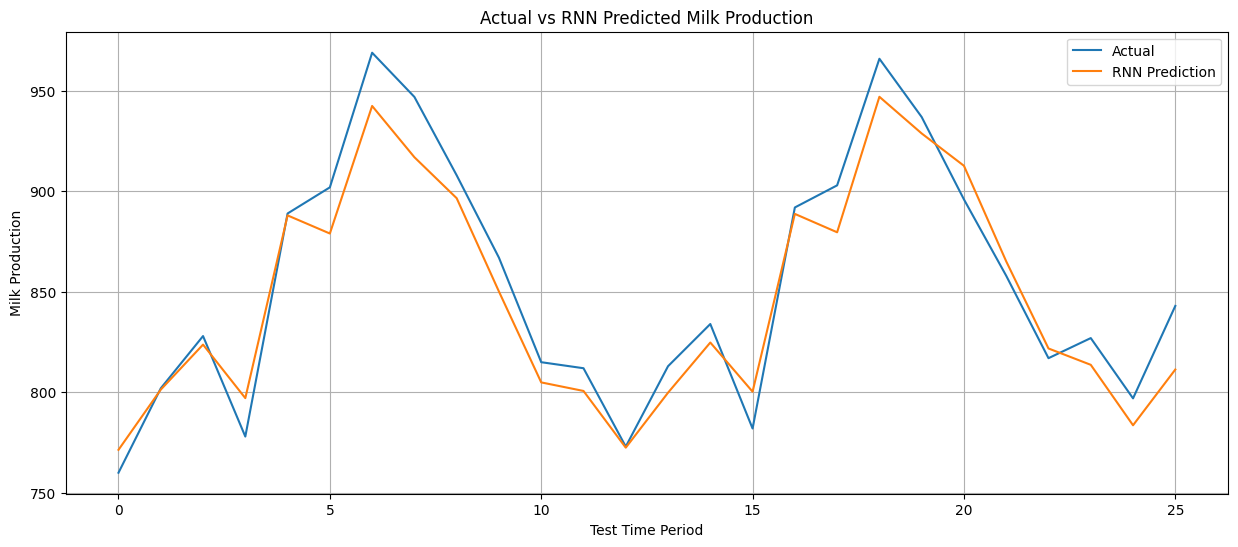

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual,
    label='Actual'
)

plt.plot(
    rnn_pred,
    label='RNN Prediction'
)

plt.title("Actual vs RNN Predicted Milk Production")
plt.xlabel("Test Time Period")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)

plt.show()

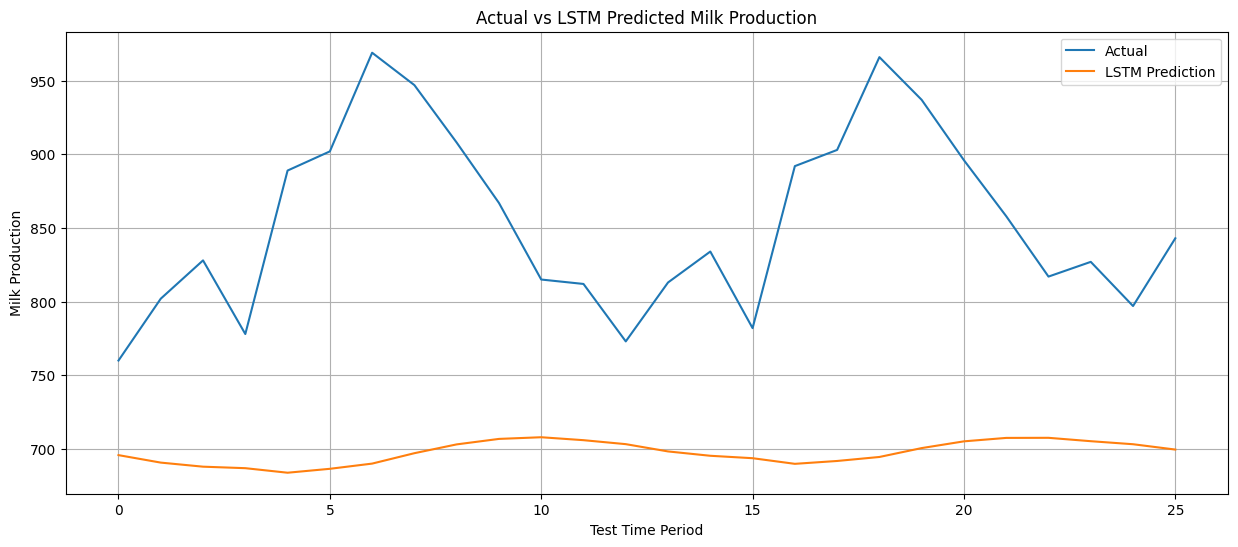

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual,
    label='Actual'
)

plt.plot(
    lstm_pred,
    label='LSTM Prediction'
)

plt.title("Actual vs LSTM Predicted Milk Production")
plt.xlabel("Test Time Period")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)

plt.show()

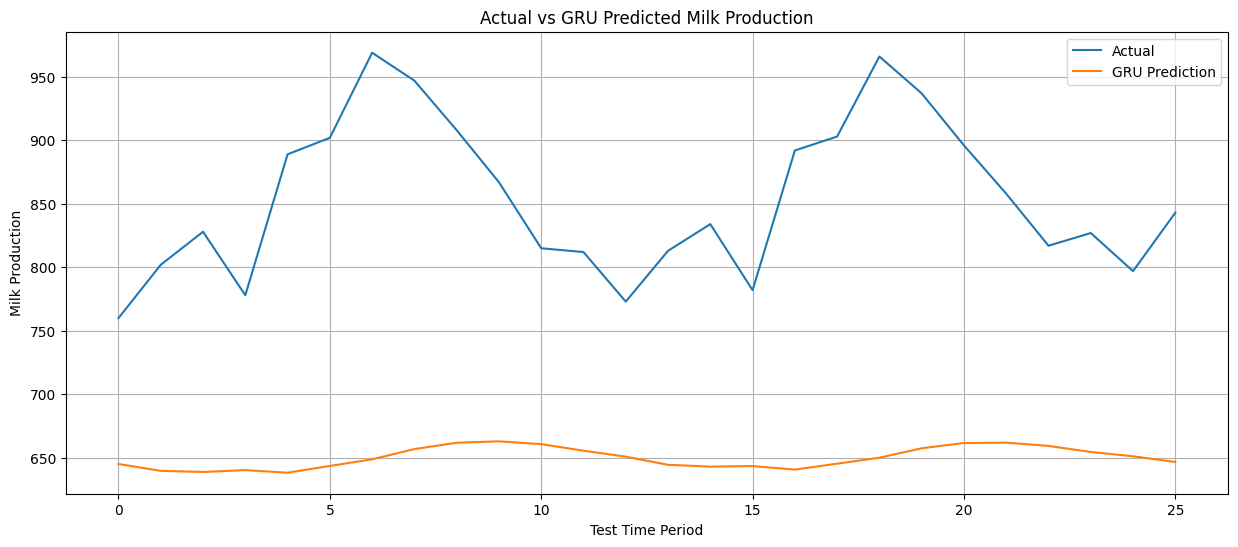

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    actual,
    label='Actual'
)

plt.plot(
    gru_pred,
    label='GRU Prediction'
)

plt.title("Actual vs GRU Predicted Milk Production")
plt.xlabel("Test Time Period")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)

plt.show()

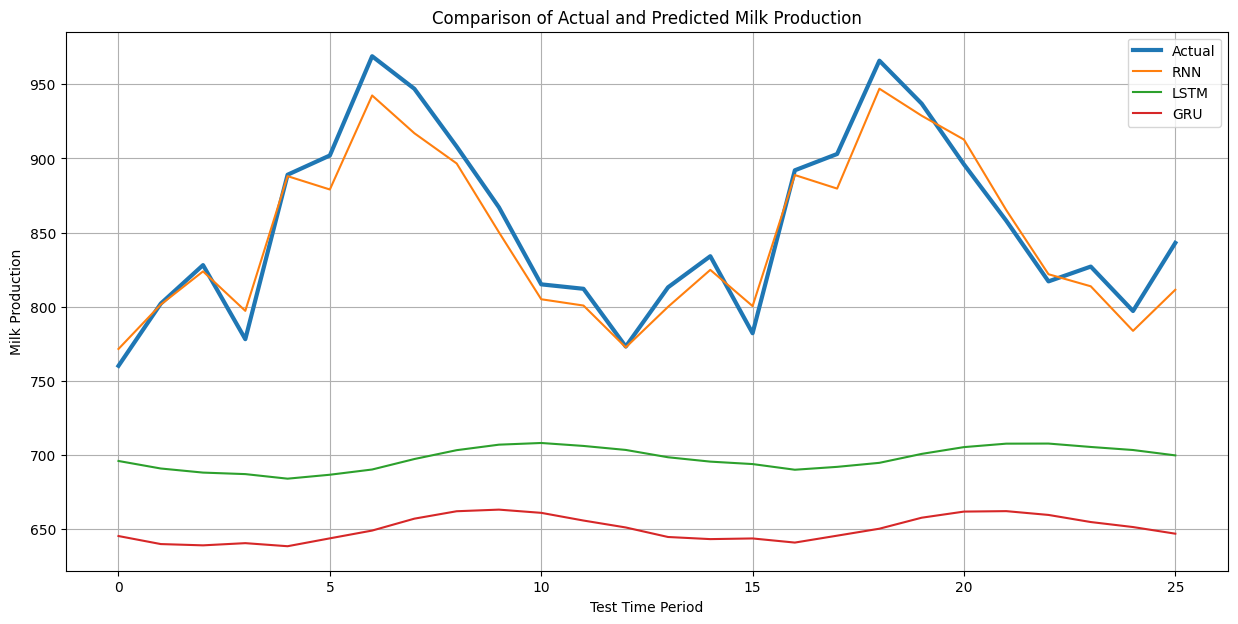

In [ ]:
plt.figure(figsize=(15, 7))

plt.plot(
    actual,
    label='Actual',
    linewidth=3
)

plt.plot(
    rnn_pred,
    label='RNN'
)

plt.plot(
    lstm_pred,
    label='LSTM'
)

plt.plot(
    gru_pred,
    label='GRU'
)

plt.title("Comparison of Actual and Predicted Milk Production")
plt.xlabel("Test Time Period")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_model_name = results.loc[
    results['RMSE'].idxmin(),
    'Model'
]

print("Best Model based on RMSE:", best_model_name)

In [ ]:
print(results.sort_values('RMSE'))

  Model        RMSE         MAE   MAPE (%)
0   RNN   15.900669   13.360868   1.545364
1  LSTM  168.597386  156.815899  17.944609
2   GRU  212.625617  204.301765  23.554457


In [ ]:
models = {
    'RNN': rnn_model,
    'LSTM': lstm_model,
    'GRU': gru_model
}

best_model = models[best_model_name]

print("Selected model:", best_model_name)

Selected model: RNN


In [ ]:
models = {
    'RNN': rnn_model,
    'LSTM': lstm_model,
    'GRU': gru_model
}

best_model_name = results.loc[
    results['RMSE'].idxmin(),
    'Model'
]

best_model = models[best_model_name]

print("Selected model:", best_model_name)

last_sequence = scaled_values[-window_size:].copy()

future_predictions_scaled = []

for i in range(12):

    input_sequence = last_sequence.reshape(
        1,
        window_size,
        1
    )

    next_prediction = best_model.predict(
        input_sequence,
        verbose=0
    )[0, 0]

    future_predictions_scaled.append(
        next_prediction
    )

    # Add prediction and remove oldest observation
    last_sequence = np.append(
        last_sequence[1:],
        [[next_prediction]],
        axis=0
    )

Selected model: RNN


In [ ]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
).flatten()

print("Next 12 Months Forecast:")
print(future_predictions)

Next 12 Months Forecast:
[835.4917  809.59503 887.29236 883.8962  936.1903  912.82214 898.4622
 860.16895 831.03125 829.3465  799.53455 826.27826]


In [ ]:
last_date = df[date_col].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df = pd.DataFrame({
    'Month': future_dates,
    'Forecasted_Milk_Production': future_predictions
})

forecast_df

,Month,Forecasted_Milk_Production
0,1976-01-01,835.491699
1,1976-02-01,809.595032
2,1976-03-01,887.292358
3,1976-04-01,883.896179
4,1976-05-01,936.190308
5,1976-06-01,912.822144
6,1976-07-01,898.462219
7,1976-08-01,860.168945
8,1976-09-01,831.031250
9,1976-10-01,829.346497


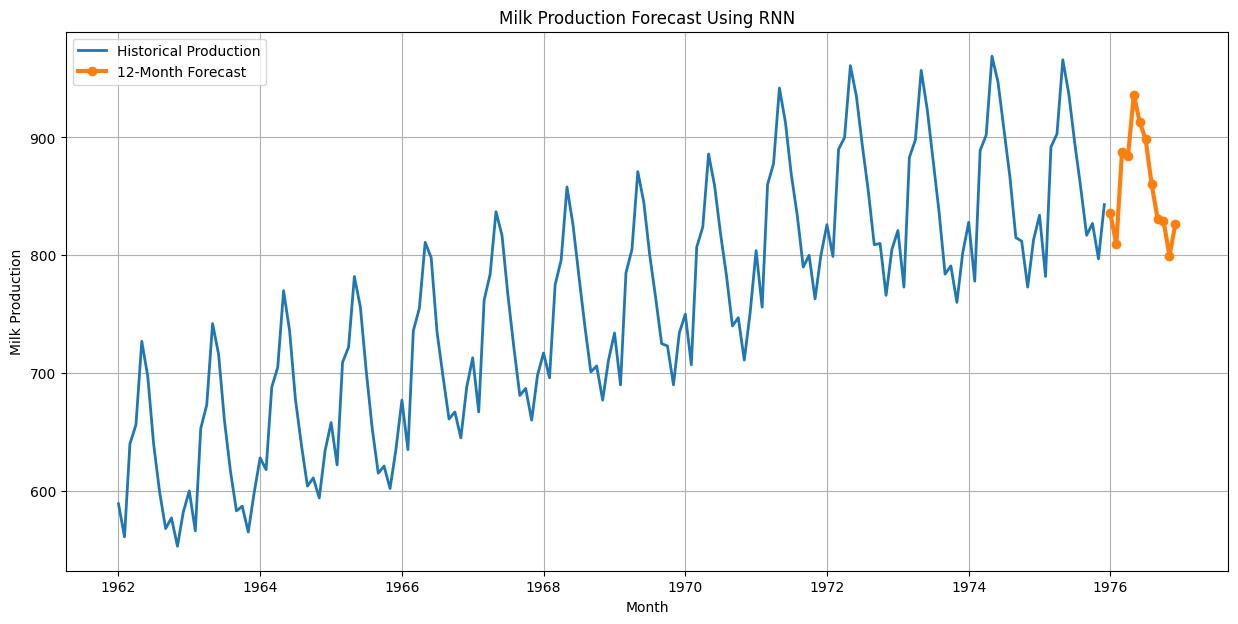

In [ ]:
plt.figure(figsize=(15, 7))

plt.plot(
    df[date_col],
    df[target_col],
    label='Historical Production',
    linewidth=2
)

plt.plot(
    forecast_df['Month'],
    forecast_df['Forecasted_Milk_Production'],
    label='12-Month Forecast',
    linewidth=3,
    marker='o'
)

plt.title(
    f"Milk Production Forecast Using {best_model_name}"
)

plt.xlabel("Month")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
forecast_df

,Month,Forecasted_Milk_Production
0,1976-01-01,835.491699
1,1976-02-01,809.595032
2,1976-03-01,887.292358
3,1976-04-01,883.896179
4,1976-05-01,936.190308
5,1976-06-01,912.822144
6,1976-07-01,898.462219
7,1976-08-01,860.168945
8,1976-09-01,831.031250
9,1976-10-01,829.346497


In [ ]:
forecast_df.to_csv(
    "milk_production_12_month_forecast.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.


In [ ]:
best_predictions = {
    'RNN': rnn_pred,
    'LSTM': lstm_pred,
    'GRU': gru_pred
}

best_pred = best_predictions[best_model_name]

residuals = actual - best_pred

residual_std = np.std(residuals)

print("Residual Standard Deviation:", residual_std)

Residual Standard Deviation: 14.076952113429556


In [ ]:
forecast_df['Lower_95'] = (
    forecast_df['Forecasted_Milk_Production']
    - 1.96 * residual_std
)

forecast_df['Upper_95'] = (
    forecast_df['Forecasted_Milk_Production']
    + 1.96 * residual_std
)

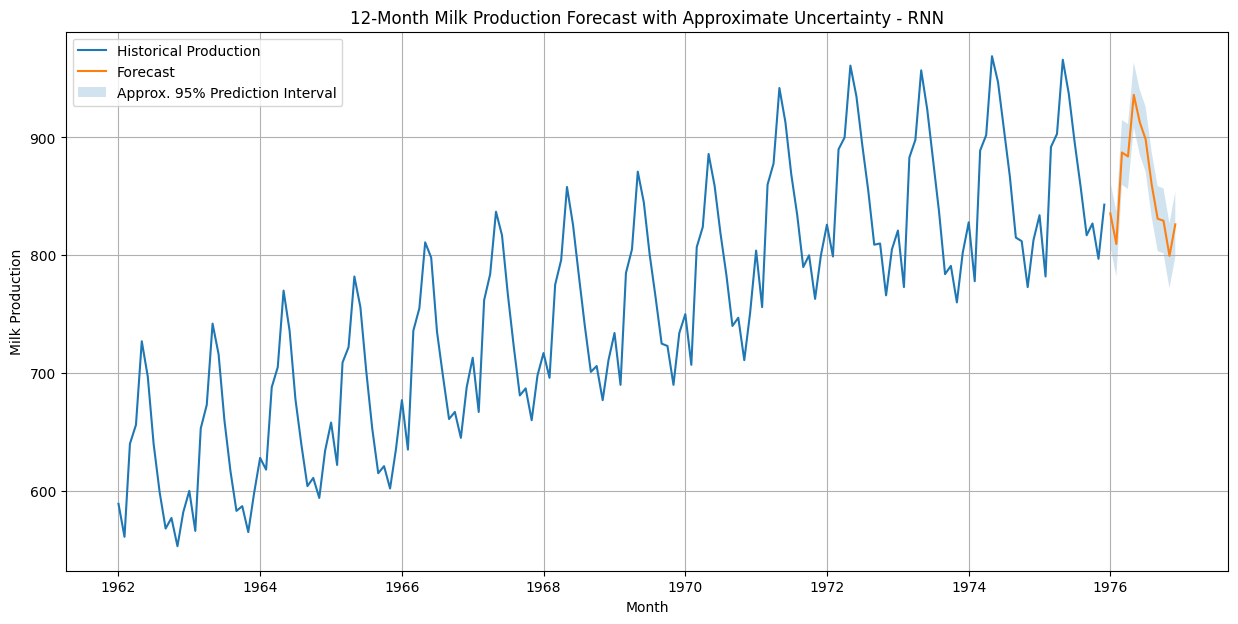

In [ ]:
plt.figure(figsize=(15, 7))

plt.plot(
    df[date_col],
    df[target_col],
    label='Historical Production'
)

plt.plot(
    forecast_df['Month'],
    forecast_df['Forecasted_Milk_Production'],
    label='Forecast'
)

plt.fill_between(
    forecast_df['Month'],
    forecast_df['Lower_95'],
    forecast_df['Upper_95'],
    alpha=0.2,
    label='Approx. 95% Prediction Interval'
)

plt.title(
    f"12-Month Milk Production Forecast with Approximate Uncertainty - {best_model_name}"
)

plt.xlabel("Month")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from tensorflow.keras.optimizers import Adam

tuned_lstm = Sequential([
    LSTM(
        128,
        activation='tanh',
        input_shape=(window_size, 1)
    ),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(1)
])

tuned_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

tuned_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,881 (292.50 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tuned_history = tuned_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

In [ ]:
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

display(
    results.sort_values(
        by='RMSE',
        ascending=True
    )
)

print("\nBest Model:", best_model_name)

FINAL MODEL COMPARISON


,Model,RMSE,MAE,MAPE (%)
0,RNN,15.900669,13.360868,1.545364
1,LSTM,168.597386,156.815899,17.944609
2,GRU,212.625617,204.301765,23.554457



Best Model: RNN
